In [23]:
from textblob import TextBlob
import nltk
nltk.download('punkt')
nltk.download('stopwords') # For removing common words
nltk.download('averaged_perceptron_tagger') # For Part-of-Speech tagging (used in lemmatization)
nltk.download('wordnet') # For lemmatization
! python -m textblob.download_corpora
# Sample reviews with associated sentiment (as provided)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\naeld\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

In [24]:
import pandas as pd
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from textblob import TextBlob, Word
from wordcloud import WordCloud
from nltk.corpus import stopwords

df = pd.read_csv("datasets/amazon.csv")
df

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1
...,...,...
19995,this app is fricken stupid.it froze on the kin...,0
19996,Please add me!!!!! I need neighbors! Ginger101...,1
19997,love it! this game. is awesome. wish it had m...,1
19998,I love love love this app on my side of fashio...,1




1.   Can you perform a sentiment analysis on the collection of product reviews, classify each one as 'positive', 'negative', or 'neutral', and then generate a bar chart to visualize the distribution of these sentiments?"

2.   convert the text to lowercase, remove punctuation and numbers, filter out common stopwords, and then lemmatize the remaining words using their appropriate part-of-speech tags.
3. fter the text has been fully preprocessed and lemmatized, could you calculate the frequency of each unique word and then display a bar graph showing the top 15 most common words?
4. generate a word cloud based on the entire corpus of lemmatized review words to provide a visual summary of the most prominent terms.
5. Visualize the frequency of nouns, verbs, adjectives in this text.



C:\Users\naeld\AppData\Local\Temp\ipykernel_75096\4222684602.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sentiment_counter.keys()), y=list(sentiment_counter.values()), palette=['green', 'red', 'blue'])


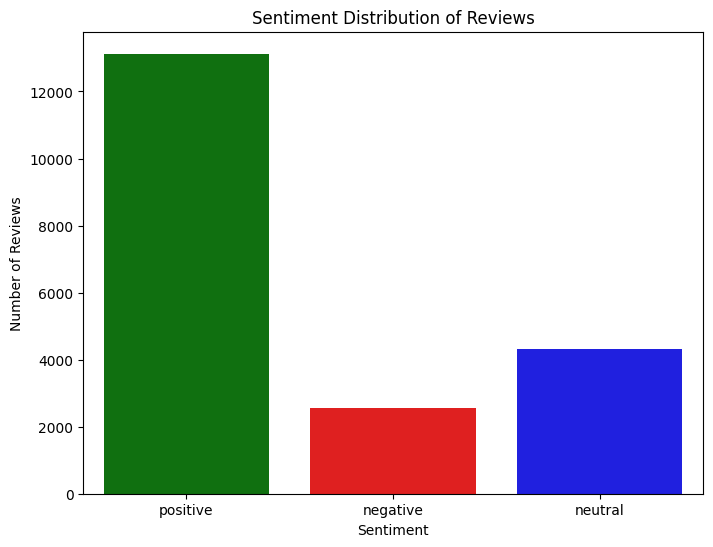

Text column used: reviewText
Reviews analyzed: 20000
Sentiment counts: Counter({'positive': 13127, 'neutral': 4324, 'negative': 2549})


In [30]:
text_col = 'reviewText' if 'reviewText' in df.columns else df.select_dtypes(include='object').columns[0]
texts = df[text_col].fillna('').astype(str)
texts = texts[texts.str.strip() != '']

polarities = texts.apply(lambda x: TextBlob(x).sentiment.polarity)
sentiments = polarities.apply(lambda p: 'positive' if p > 0.1 else ('negative' if p < -0.1 else 'neutral'))

sentiment_counter = Counter(sentiments)

plt.figure(figsize=(8, 6))
sns.barplot(x=list(sentiment_counter.keys()), y=list(sentiment_counter.values()), palette=['green', 'red', 'blue'])
plt.title('Sentiment Distribution of Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

print('Text column used:', text_col)
print('Reviews analyzed:', len(texts))
print('Sentiment counts:', sentiment_counter)

In [26]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))


def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'
    if tag.startswith('V'):
        return 'v'
    if tag.startswith('N'):
        return 'n'
    if tag.startswith('R'):
        return 'r'
    return 'n'

all_lemmas = []
all_pos_tags = []

for text in texts:
    clean_text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    if clean_text == '':
        continue

    for word, tag in TextBlob(clean_text).tags:
        if word in stop_words or len(word) <= 1:
            continue
        lemma = Word(word).lemmatize(get_wordnet_pos(tag))
        all_lemmas.append(lemma)
        all_pos_tags.append(tag)

print('Number of lemmatized tokens:', len(all_lemmas))

Number of lemmatized tokens: 328184


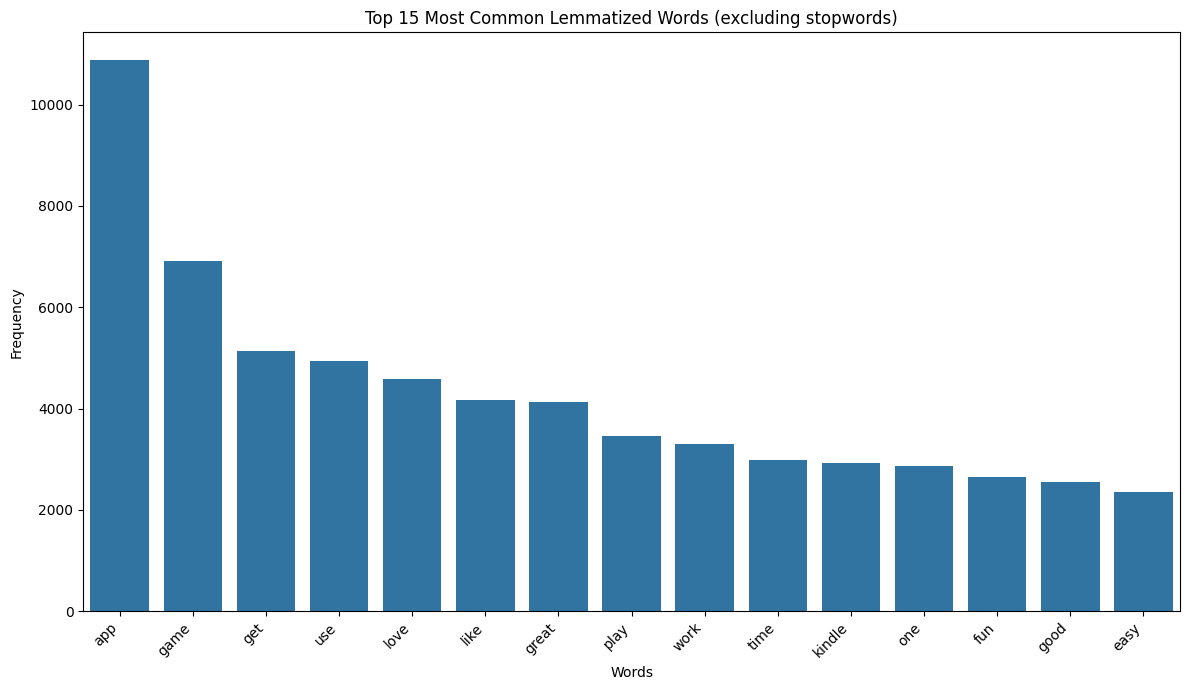

In [31]:
word_counts = Counter(all_lemmas)
top_15 = word_counts.most_common(15)

if len(top_15) > 0:
    words, counts = zip(*top_15)
    plt.figure(figsize=(12, 7))
    sns.barplot(x=list(words), y=list(counts))
    plt.title('Top 15 Most Common Lemmatized Words (excluding stopwords)')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No words found after preprocessing.')

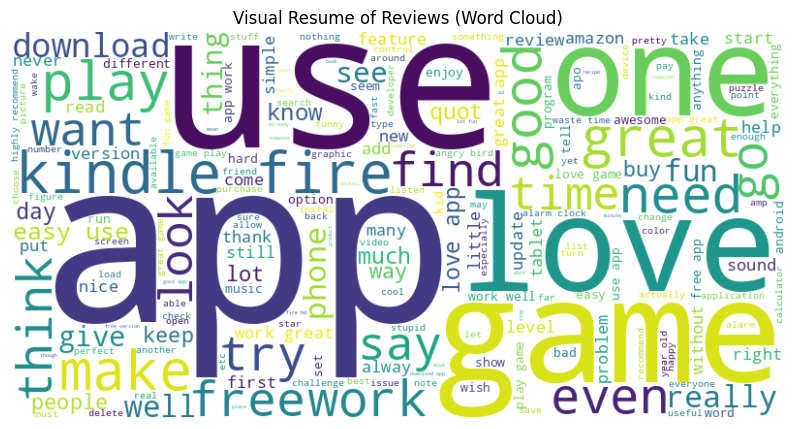

In [32]:
corpus = ' '.join(all_lemmas)
if corpus.strip() != '':
    wc = WordCloud(width=800, height=400, background_color='white').generate(corpus)
    plt.figure(figsize=(10, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Visual Resume of Reviews (Word Cloud)')
    plt.show()
else:
    print('No words available for word cloud.')

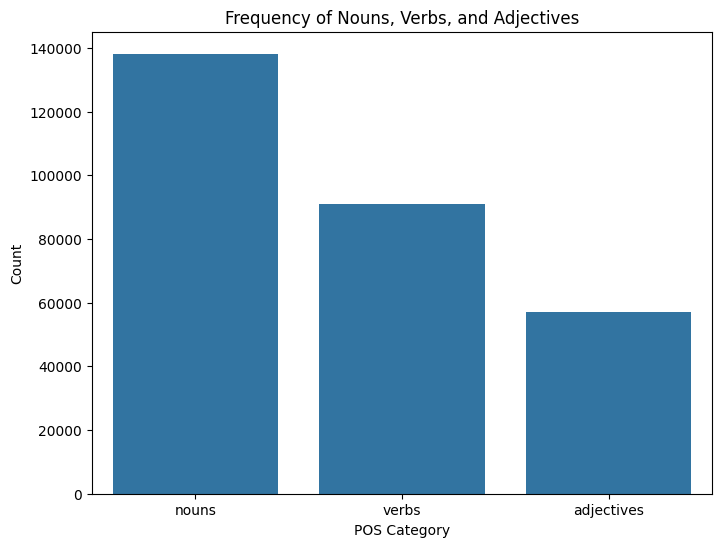

In [33]:
pos_counts = Counter({'nouns': 0, 'verbs': 0, 'adjectives': 0})
for tag in all_pos_tags:
    if tag.startswith('N'):
        pos_counts['nouns'] += 1
    elif tag.startswith('V'):
        pos_counts['verbs'] += 1
    elif tag.startswith('J'):
        pos_counts['adjectives'] += 1

plt.figure(figsize=(8, 6))
sns.barplot(x=['nouns', 'verbs', 'adjectives'], y=[pos_counts['nouns'], pos_counts['verbs'], pos_counts['adjectives']])
plt.title('Frequency of Nouns, Verbs, and Adjectives')
plt.xlabel('POS Category')
plt.ylabel('Count')
plt.show()